In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display

HERE = Path.cwd()
if not (HERE / "data" / "Occupancy_Estimation.csv").exists():
    HERE = HERE / "assignment-1-room-occupancy"
if not (HERE / "data" / "Occupancy_Estimation.csv").exists():
    raise FileNotFoundError("Open Jupyter from the assignment folder or repository root.")

COLORS = ["#4279a3", "#d57249"]

In [2]:
df = pd.read_csv(HERE / "data" / "Occupancy_Estimation.csv")
print(f"{len(df):,} observations, {len(df.columns)} columns")
display(df.head())
print("Missing values:", int(df.isna().sum().sum()))

10,129 observations, 19 columns


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,2017/12/22,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,2017/12/22,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,2017/12/22,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,2017/12/22,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


Missing values: 0


In [3]:
df["timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"], format="%Y/%m/%d %H:%M:%S"
)
df = df.sort_values("timestamp").reset_index(drop=True)
df["occupied"] = (df["Room_Occupancy_Count"] > 0).astype(int)

display(df.groupby("Date").agg(
    observations=("occupied", "size"),
    occupied_observations=("occupied", "sum"),
))

,observations,occupied_observations
Date,,
2017/12/22,1462,825
2017/12/23,2779,782
2017/12/24,1064,0
2017/12/25,1716,0
2017/12/26,1063,0
2018/01/10,997,294
2018/01/11,1048,0


In [4]:
split_date = "2018-01-01"
train = df[df["timestamp"] < split_date].copy()
test = df[df["timestamp"] >= split_date].copy()
y_train = train["occupied"].to_numpy()
y_test = test["occupied"].to_numpy()

assert train["timestamp"].max() < test["timestamp"].min()
assert set(y_train) == {0, 1} and set(y_test) == {0, 1}

split_summary = []
for name, frame in [("train", train), ("test", test)]:
    split_summary.append({
        "split": name, "rows": len(frame),
        "occupied": int(frame["occupied"].sum()),
        "start": str(frame["timestamp"].min()),
        "end": str(frame["timestamp"].max()),
    })
display(pd.DataFrame(split_summary))

,split,rows,occupied,start,end
0,train,8084,1607,2017-12-22 10:49:41,2017-12-26 09:10:01
1,test,2045,294,2018-01-10 15:25:48,2018-01-11 09:00:09


In [5]:
features = {
    "Two sensors": ["S1_Temp", "S5_CO2"],
    "More sensors": ["S1_Temp", "S5_CO2", "S1_Light", "S1_Sound", "S6_PIR", "S7_PIR"],
}

assert np.isfinite(df[features["More sensors"]].to_numpy(dtype=float)).all()
display(train[features["More sensors"]].head())

,S1_Temp,S5_CO2,S1_Light,S1_Sound,S6_PIR,S7_PIR
0,24.94,390,121,0.08,0,0
1,24.94,390,121,0.93,0,0
2,25.00,390,121,0.43,0,0
3,25.00,390,121,0.41,0,0
4,25.00,390,121,0.18,0,0


In [6]:
prepared = {}
for name, columns in features.items():
    X_train = train[columns].to_numpy(dtype=float)
    X_test = test[columns].to_numpy(dtype=float)
    mean = X_train.mean(axis=0)
    scale = X_train.std(axis=0)
    scale[scale == 0] = 1.0
    prepared[name] = {
        "X_train": (X_train - mean) / scale,
        "X_test": (X_test - mean) / scale,
        "mean": mean,
        "scale": scale,
    }

display(pd.DataFrame(
    prepared["Two sensors"]["X_train"][:5], columns=features["Two sensors"]
))

,S1_Temp,S5_CO2
0,-1.472631,-0.380083
1,-1.472631,-0.380083
2,-1.308574,-0.380083
3,-1.308574,-0.380083
4,-1.308574,-0.380083


In [7]:
class Perceptron:
    def __init__(self, eta=0.01, n_iter=30, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(0.0, 0.01, size=X.shape[1])
        self.b_ = 0.0
        self.errors_ = []

        for _ in range(self.n_iter):
            indices = rgen.permutation(len(y))
            epoch_errors = 0
            for i in indices:
                xi, target = X[i], y[i]
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                epoch_errors += int(update != 0.0)
            self.errors_.append(epoch_errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

In [8]:
eta = 0.01
n_iter = 30
random_state = 1
models = {}

for name, data in prepared.items():
    ppn = Perceptron(eta=eta, n_iter=n_iter, random_state=random_state)
    ppn.fit(data["X_train"], y_train)
    models[name] = ppn
    print(f"{name}: bias = {ppn.b_:.4f}")
    display(pd.DataFrame({"feature": features[name], "weight": ppn.w_}))

Two sensors: bias = -0.0300


,feature,weight
0,S1_Temp,0.019408
1,S5_CO2,-0.034510


More sensors: bias = -0.3400


,feature,weight
0,S1_Temp,-0.157882
1,S5_CO2,0.241543
2,S1_Light,0.497018
3,S1_Sound,0.018133
4,S6_PIR,0.011974
5,S7_PIR,-0.041019


In [9]:
def plot_training(models):
    fig, ax = plt.subplots(figsize=(8, 4))
    for name, model in models.items():
        ax.plot(range(1, len(model.errors_) + 1), model.errors_, label=name)
    ax.set(xlabel="Epoch", ylabel="Updates during the epoch",
           title="Perceptron training updates")
    ax.legend()
    fig.tight_layout()
    plt.show()

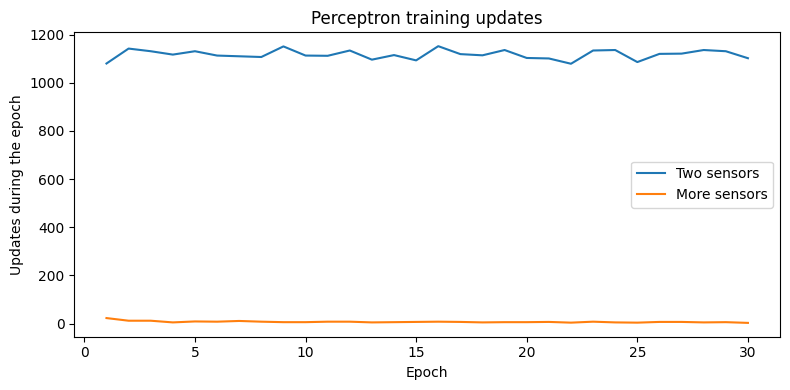

In [10]:
plot_training(models)

In [11]:
def evaluate(y, pred):
    tn = int(np.sum((y == 0) & (pred == 0)))
    fp = int(np.sum((y == 0) & (pred == 1)))
    fn = int(np.sum((y == 1) & (pred == 0)))
    tp = int(np.sum((y == 1) & (pred == 1)))
    recall = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0
    return {
        "accuracy": (tp + tn) / len(y),
        "balanced_accuracy": (recall + specificity) / 2,
        "occupied_precision": precision,
        "occupied_recall": recall,
        "false_empty": fn,
        "false_occupied": fp,
        "true_empty": tn,
        "true_occupied": tp,
    }

In [12]:
predictions = {}
scores = [{"model": "Always empty", **evaluate(y_test, np.zeros_like(y_test))}]
for name, ppn in models.items():
    pred = ppn.predict(prepared[name]["X_test"])
    predictions[name] = pred
    scores.append({"model": name, **evaluate(y_test, pred)})

metrics = pd.DataFrame(scores).set_index("model")
display(metrics.round(4))

,accuracy,balanced_accuracy,occupied_precision,occupied_recall,false_empty,false_occupied,true_empty,true_occupied
model,,,,,,,,
Always empty,0.8562,0.5000,0.0,0.0000,294,0,1751,0
Two sensors,0.8562,0.5000,0.0,0.0000,294,0,1751,0
More sensors,0.9100,0.6871,1.0,0.3741,184,0,1751,110


In [13]:
def plot_confusion(matrices):
    fig, axes = plt.subplots(1, len(matrices), figsize=(10, 4))
    for ax, (name, matrix) in zip(axes, matrices.items()):
        ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max(matrix.max(), 1))
        for (row, col), value in np.ndenumerate(matrix):
            ax.text(col, row, str(value), ha="center", va="center",
                    color="white" if value > matrix.max() / 2 else "black", fontsize=15)
        ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Empty", "Occupied"],
               yticklabels=["Empty", "Occupied"], xlabel="Predicted", ylabel="Actual",
               title=name)
    fig.tight_layout()
    plt.show()

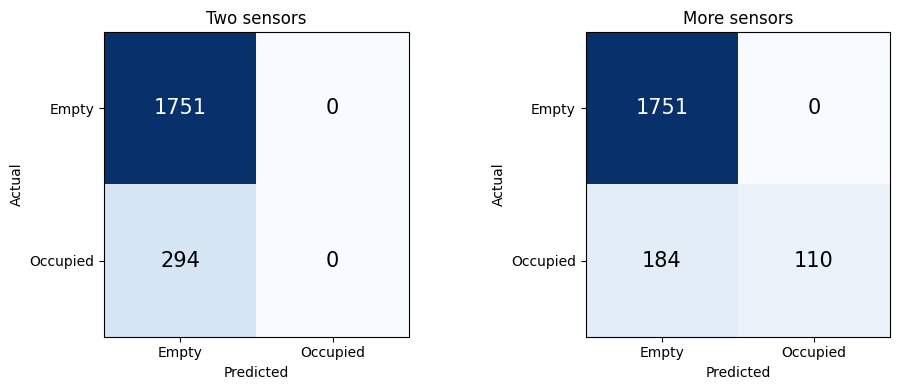

In [14]:
matrices = {}
for name in models:
    row = metrics.loc[name]
    matrices[name] = np.array([
        [row["true_empty"], row["false_occupied"]],
        [row["false_empty"], row["true_occupied"]],
    ], dtype=int)
plot_confusion(matrices)

In [15]:
def plot_decision_regions(X, y, classifier, mean, scale):
    low = X.min(axis=0)
    high = X.max(axis=0)
    margin = np.maximum((high - low) * 0.05, 0.1)
    xx, yy = np.meshgrid(
        np.linspace(low[0] - margin[0], high[0] + margin[0], 250),
        np.linspace(low[1] - margin[1], high[1] + margin[1], 250),
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    pred = classifier.predict((grid - mean) / scale).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.contourf(xx, yy, pred, levels=[-0.5, 0.5, 1.5],
                cmap=ListedColormap(COLORS), alpha=0.18)
    for label, name, marker in [(0, "Empty (actual)", "o"), (1, "Occupied (actual)", "^")]:
        ax.scatter(X[y == label, 0], X[y == label, 1], s=13,
                   color=COLORS[label], marker=marker, alpha=0.55, label=name)
    ax.set(xlabel="S1 temperature (°C)", ylabel="CO₂ (ppm)",
           title="Two sensors: test observations and predicted regions")
    ax.legend()
    fig.tight_layout()
    plt.show()

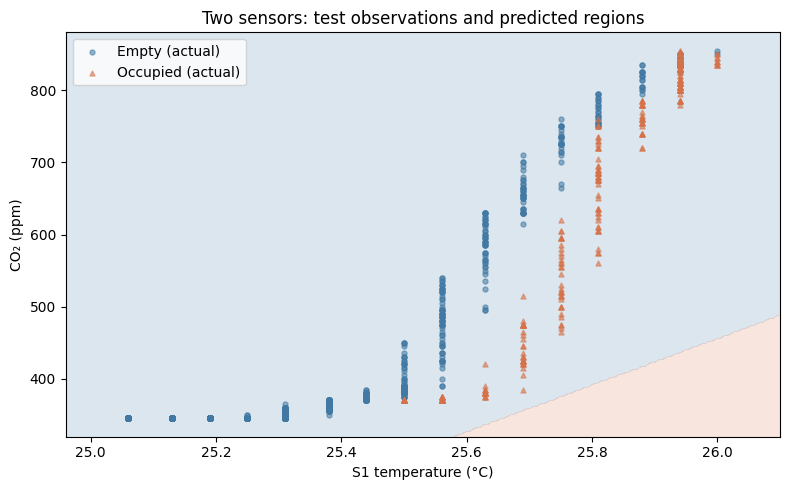

In [16]:
name = "Two sensors"
plot_decision_regions(
    test[features[name]].to_numpy(), y_test, models[name],
    prepared[name]["mean"], prepared[name]["scale"],
)

In [17]:
def plot_timeline(test, predictions):
    dates = test["timestamp"].dt.date
    days = dates.unique()
    fig, axes = plt.subplots(len(days), 1, figsize=(11, 3 * len(days)), squeeze=False)
    for ax, day in zip(axes[:, 0], days):
        selected = (dates == day).to_numpy()
        time = test.loc[selected, "timestamp"]
        actual = test.loc[selected, "occupied"].to_numpy()
        ax.step(time, actual, where="post", color="black", linewidth=2, label="Actual")
        for i, (name, pred) in enumerate(predictions.items()):
            ax.step(time, pred[selected] + 0.035 * (i + 1), where="post",
                    alpha=0.7, label=name, color=COLORS[i])
        ax.set(yticks=[0, 1], yticklabels=["Empty", "Occupied"], ylim=(-0.15, 1.2),
               title=str(day), xlabel="Recorded time")
        ax.legend(loc="upper right", ncol=3)
    fig.suptitle("Test days: actual occupancy and predictions (slightly offset)")
    fig.tight_layout()
    plt.show()

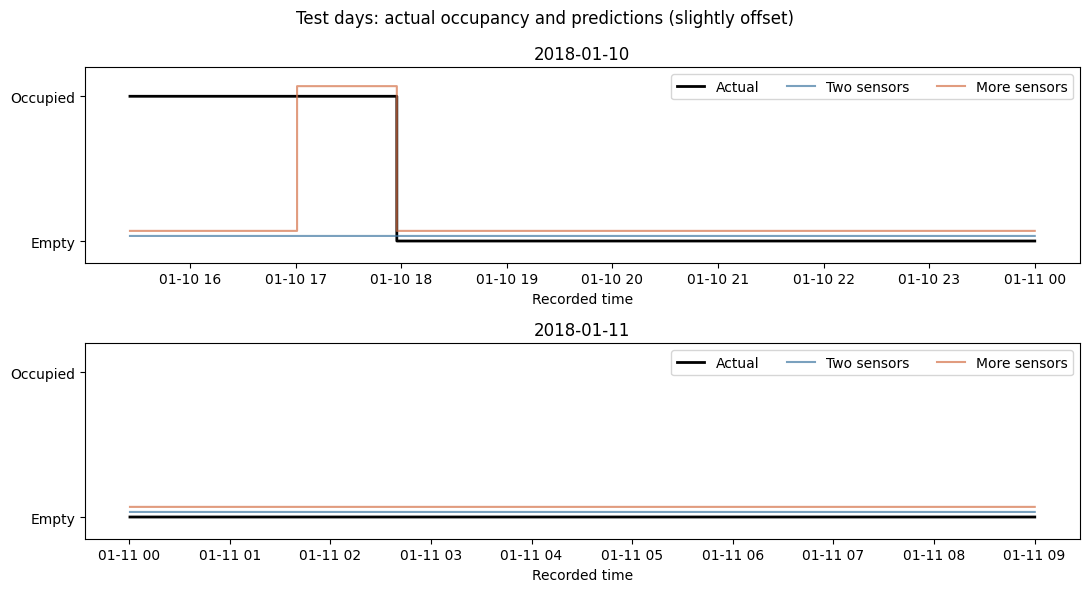

In [18]:
plot_timeline(test, predictions)

In [19]:
for name in models:
    row = metrics.loc[name]
    print(
        f"{name}: detected {int(row['true_occupied'])}/{int(y_test.sum())} "
        f"occupied observations; accuracy {row['accuracy']:.2%}; "
        f"occupied recall {row['occupied_recall']:.2%}."
    )

Two sensors: detected 0/294 occupied observations; accuracy 85.62%; occupied recall 0.00%.
More sensors: detected 110/294 occupied observations; accuracy 91.00%; occupied recall 37.41%.
